##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 1

**Group name:** Databazen😎

**Student names & numbers:**
* [Xander UijtdeHaag] - [Student no.100546]
* [Jamie Eversdijk] - [Student no.000101617]
* [Jero den Exter] - [Student no.000100883]


---

## 0. Iteration setup

**Import libraries**

In [2]:
%pip install pandas
%pip install matplotlib
%pip install scikit-learn

import pandas as pd
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Load dataset(s)**

In [3]:
df = pd.read_csv('Data/Sus scrofa.csv')

C:\Users\User\AppData\Local\Temp\ipykernel_20132\1270535641.py:1: DtypeWarning: Columns (0: Sus scrofa) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Data/Sus scrofa.csv')


---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)**

**Business objective(s)**

Wij willen inzicht krijgen in de leefgebieden in Nederland van waar wilde zwijnen het vaakst voorkomen van op zijn minst 20 verschillende plaatsen zodat wij weten waar de zwijnen leven tussen 2010 en 2025.


**Acceptence criteria(s)**
Duidelijk inzicht voor waar de meeste wilde zwijnen leven in Nederland

Minstens 20 verschillende plaatsen halen uit de data.

Alleen data tussen 2010 en 2025 gebruiken

Gebieden met hoge en lage hoeveelheden van zwijnen zijn te scheiden.

**Data management goal(s)**

We houden de data netjes en overzichtelijk in een CSV-bestand op onze GitHub. We zorgen ervoor dat de data betrouwbaar blijft door goed te checken of er fouten of missende data is in de dataset.

**Data mining goal(s)**
Met behulp van een classificatie model inzicht krijgen waar de meeste wilde zwijnen van Nederland leven tussen 2010 en 2025. We hebben gekozen voor dit model omdat dit model goed omgaat met geografische data en minder gevoelig is voor uitschieters in de waarnemingen.

**Success criteria**
Het model heeft een accuracy van 80% op het vinden van wilde zwijnen tegenover de testset aan het einde van dit project.

Het model heeft een recall van 75% en een precision van op zijn minst 70% op de geclassificeerde gebieden. De criteria moet behaald zijn bij de evaluatie van het model op de testset.


*Determine success criteria for this iteration (the benchmark)*

Recall (75%)
Recall kijkt naar van alle gebieden met "veel" zwijnen hoeveel het model er correct heeft voorspeld. Het model zal dus kijken of het alle zwijngebieden die echt zijn ook goed heeft voorspeld. Wij kiezen voor een recall van 75%, omdat dit ervoor zorgt dat de meest belangrijke leefgebieden worden meegenomen. Dit is een realistische grens in onze ogen.

Precision (80%)
Precision geeft aan hoe vaak een voorspeld gebied met “veel” wilde zwijnen ook daadwerkelijk klopt. Wij kiezen voor een precision van 80%, omdat het belangrijk is dat de gebieden die het model aanwijst als "veel" wilde zwijnen ook echt betrouwbaar zijn. Dit zorgt ervoor dat er minder foute gegevens zijn over de zwijnen. Wij vinden dus het correct voorspellen van de gebieden met "veel" wilde zwijnen iets belangrijker als het vinden van alle gebieden met "veel" wilde zwijnen.


**Exploratory data analysis**

Hier hebben we de dataset geanalyseerd om er achter te komen welke info er beschikbaar is over de wilde zwijen. Door df.info() te doen zien we dat de dataset heel groot is met 12.558.786 rijen en 6 kolommen. De kolommen hebben geografische coördinaten (decimalLatitude, decimalLongitude), wat nodig is om de locatie van de zwijnen te bepalen, de datum van de waarneming (eventDate), wat cruciale informatie is om te zien op het binnen 2010 en 2025 valt, en het aantal waarnemingen, het totaal aantal in de waarnemingen (total_observations), wat helpt met het vinden van "hotspots". De kolom Sus scrofa is onze doelvariabele voor het identificeren van de zwijnen.

Met df.describe() zien we dat de coördinaten (Latitude rond 52.2 en Longitude rond 5.5) de goede waarden zijn voor Nederland. Het gemiddelde aantal waarneming per record is laag, maar er zijn wel uitschieters tot wel 1.637 waarnemingen in de speciesgroup_observations. Met de check df.isna().sum() laten we zien dat de dataset bijna volledig is, er missen maar 2 waarden in de kolom total_observations. Dit is heel weinig vergeleken met het toaal van 12 miljoen rijen, dus de kwaliteit van de data is hoog. Aan de hand van de EDA weten we dat de data representatief is voor Nederland en dat de data schoon genoeg is om mee te werken.

Door df.describe() zien we dat veel waarnemingen van zwijnen veel geclusterd zijn. Het is mogelijk dat er een bias is van meldingen in gebieden waar veel mensen wandelen, terwijl er in rustige gebieden misschien ook zwijnen zitten die niet gemeld worden. Hier moeten we rekening mee houden als we ons model trainen.

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 6 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  str    
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Sus scrofa                 Int64  
dtypes: Int64(1), float64(3), int64(1), str(1)
memory usage: 586.9 MB


In [5]:
df.head()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Sus scrofa
0,50.75,5.65,2010-01-01,0.0,0,0
1,50.75,5.65,2010-01-02,26.0,0,0
2,50.75,5.65,2010-01-03,3.0,0,0
3,50.75,5.65,2010-01-04,0.0,0,0
4,50.75,5.65,2010-01-05,0.0,0,0


In [32]:
df.describe()

,decimalLatitude,decimalLongitude,total_observations,speciesgroup_observations
count,1.255879e+07,1.255879e+07,1.255878e+07,1.255879e+07
mean,5.222995e+01,5.532896e+00,8.125083e+00,2.262421e-01
std,6.647267e-01,8.779710e-01,4.830242e+01,2.521836e+00
min,3.500000e+00,3.350000e+00,0.000000e+00,0.000000e+00
25%,5.170000e+01,4.900000e+00,0.000000e+00,0.000000e+00
50%,5.220000e+01,5.650000e+00,1.000000e+00,0.000000e+00
75%,5.280000e+01,6.200000e+00,6.000000e+00,0.000000e+00
max,5.350000e+01,5.340000e+01,1.000400e+05,1.637000e+03


In [33]:
df.isna().sum()

decimalLatitude              0
decimalLongitude             0
eventDate                    0
total_observations           2
speciesgroup_observations    0
Sus scrofa                   0
dtype: int64

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Include summary statistics and descriptions of data types below. Describe your findings.*

Tijdens de eda zijn we erachter gekomen dat datatypes zijn float, object en een int. Wat hier van toepassing is dat de Sus scrofa een object is en om deze mee te brengen in visualisaties moet dit veranderd worden naar een integer.

In [7]:
# Controleer de kolomtype-conversie voor 'Sus scrofa'
df['Sus scrofa'] = pd.to_numeric(df['Sus scrofa'], errors='coerce').astype('Int64')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 6 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  str    
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Sus scrofa                 Int64  
dtypes: Int64(1), float64(3), int64(1), str(1)
memory usage: 586.9 MB


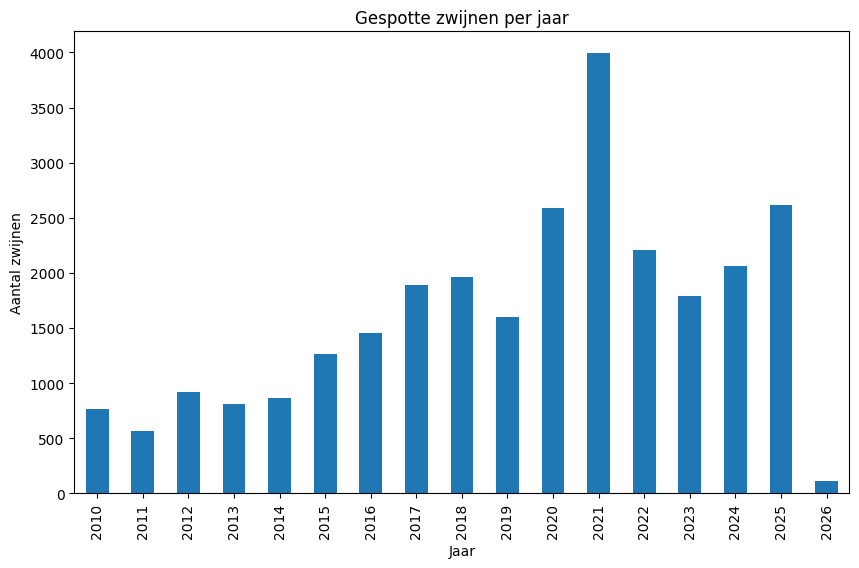

In [39]:
# Maak een barchart van de zwijnen per jaar uit eventDate

df['eventDate'] = pd.to_datetime(df['eventDate'], errors='coerce')
df['year'] = df['eventDate'].dt.year

# Jaarlijkse som van de zwijnen per jaar
perjaar = df.groupby('year')['Sus scrofa'].sum().dropna()

ax = perjaar.plot(kind='bar', figsize=(10, 6))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))
plt.title('Gespotte zwijnen per jaar')
plt.xlabel('Jaar')
plt.ylabel('Aantal zwijnen')
plt.show()

In deze grafiek zie je het aantal gespotte zwijnen van 2010 t/m 2026. Wat hier vooral opvalt is de piek in 2021 vergeleken met de jaren daarna. Normaal gezien als je van 2020 naar 2021 gaat met zo'n groei kan het aan meerdere factoren liggen, maar het feit dat de hoeveelheid zwijnen gespot weer terug zakt in 2022 is frappant. Dit verschijnsel kan liggen aan het feit dat er gewoon meer zwijnen waren in 2021 of dat mensen weer naar buiten gingen vanwege de piek van coronavirus het jaar ervoor. Over het coronavirus gesproken is het apart dat 2020 het 2 na hoogste getal is van alle jaren, omdat er toen juist werd geadviseerd om zo veel mogelijk binnen te blijven. 

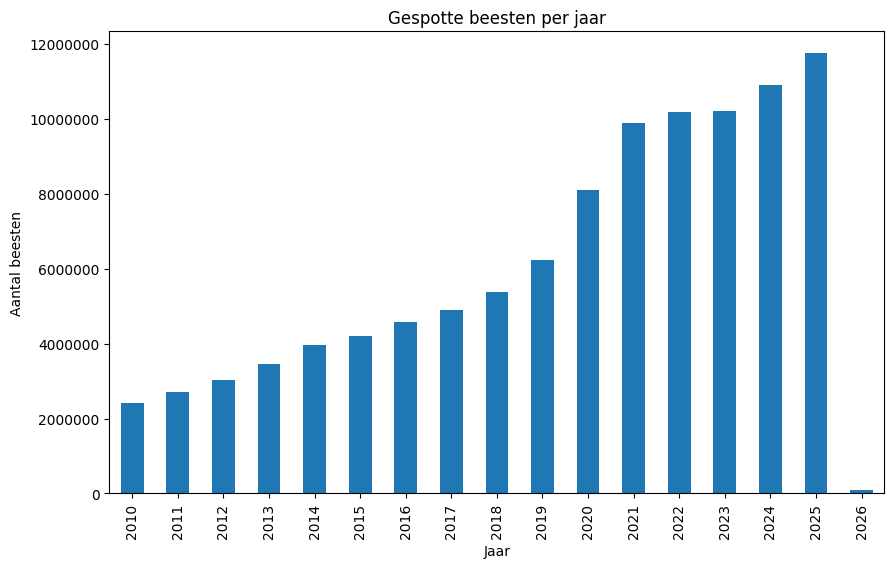

In [38]:
df['eventDate'] = pd.to_datetime(df['eventDate'], errors='coerce')
df['year'] = df['eventDate'].dt.year

# Jaarlijkse som van de beesten per jaar
perjaar = df.groupby('year')['total_observations'].sum().dropna()

ax = perjaar.plot(kind='bar', figsize=(10, 6))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))
plt.title('Gespotte beesten per jaar')
plt.xlabel('Jaar')
plt.ylabel('Aantal beesten')
plt.show()

Deze grafiek is te zien hoeveel keer er een foto werd ingediend in de app per jaar, hier is het duidelijk dat er in de app steeds meer beesten worden ingediend in de loop van de jaren. Dit ligt vooral aan het feit dat de app populairder is geworden vergeleken met vroeger. Dit verklaart ook de steigende lijn bij de zwijnen grafiek.

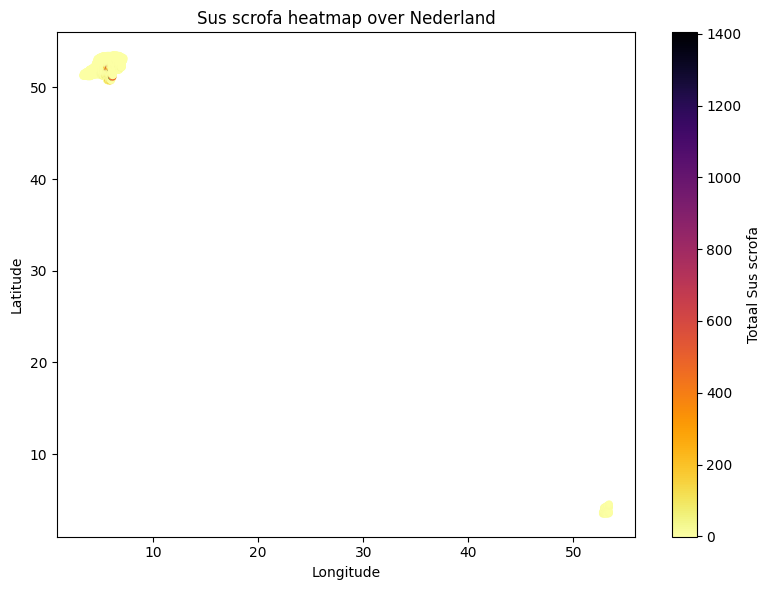

In [37]:
# Heatmap van Sus scrofa over Nederland met longitude en latitude
import numpy as np

# Zorg dat de locatiekolommen numeriek zijn
df['decimalLatitude'] = pd.to_numeric(df['decimalLatitude'], errors='coerce')
df['decimalLongitude'] = pd.to_numeric(df['decimalLongitude'], errors='coerce')

heatmap_df = df.dropna(subset=['decimalLatitude', 'decimalLongitude', 'Sus scrofa'])

# Aggregeer Sus scrofa per locatie
agg_df = heatmap_df.groupby(['decimalLongitude', 'decimalLatitude'])['Sus scrofa'].sum().reset_index()

plt.figure(figsize=(8, 6))
plt.scatter(
    agg_df['decimalLongitude'],
    agg_df['decimalLatitude'],
    c=agg_df['Sus scrofa'].astype(float),
    cmap='inferno_r',
    s=20
)
plt.colorbar(label='Totaal Sus scrofa')
plt.title('Sus scrofa heatmap over Nederland')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

Deze heatmap geeft weer waar zwijnen het meeste worden gespot, wat hier heel duidelijk opvalt is dat er zogenaamd zwijnen zijn gespot rechtsonderin van de map. Dit kan betekenen dat iemand zin had om bijvoorbeeld in australië zwijnen te publiceren op de app, of dat de longitude en lattitude wat wordt gebruikt om de locatie te bepalen verkeerd zijn ingevuld in de dataset. We gaan dus uitzoeken hoe dit is gebeurd en of dit op te lossen is zodat we dieper in de map kunnen kijken aangezien door deze verschijnselen de hele map is uitgezoomd, en dus niet goed kunnen zien hoe dit in Nederland is verdeeld.

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Describe and justify the creation of your simple benchmark model to predict Galactic_Credits*

In [9]:
# CODE CELL: Model training and setup code
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

# Target is galacric credits
target = df_final['Galactic_Credits']
# Splitsen data in een train en test set
target_train, target_test = train_test_split(target, test_size=0.2, random_state=42)

# Voorspelling model
value = target_train.median()

pred_train = [value] * len(target_train)

pred_test = [value] * len(target_test)

Train_test_split is de methode die wij hebben geleerd om een dataset op te delen, zodat we een kolom kunnen gebruiken om toekomstige waardes te voorspellen.

Hierin wordt de voorspelling gemaakt met train_test_split wat wordt opgedeeld in 80% train en 20% split wat de test_size=0.2 aangeeft. De random state is 42 wat aangeeft dat het altijd hetzelfde wordt verdeeld en je het vaker opnieuw kan gebruiken. Tot slot maak je de voorspelling van de train d.m.v. het gemiddelde te pakken van de target en dat * target_train en -test te doen.

**Testing and performance**
*Describe how you tested the model and interpret the metrics. Make sure to present the metrics in a clear overview.*

In [12]:
# CODE CELL: Model evaluation code
# MAE en RMSE van train en test
print('MAE of train set:', mean_absolute_error(target_train, pred_train))
print('MAE of test set:', mean_absolute_error(target_test, pred_test))
print('RMSE of train set:', root_mean_squared_error(target_train, pred_train))
print('RMSE of test set:', root_mean_squared_error(target_test, pred_test))

MAE of train set: 11079.722925715712
MAE of test set: 11058.98746912381
RMSE of train set: 14663.368917696056
RMSE of test set: 14594.354455063114


MAE en RMSE van de train is de daadwerkelijke waardes van Galactic_Credits en de test is de voorspelling ervan. De MAE van de trainingsset is ongeveer 11.079 en van de testset ongeveer 11.058. Het verschil van 11 Galactic_Credits is zeer klein, wat aangeeft dat het model niet ver afwijkt. Het verschil in RMSE tussen train en test is ongeveer 69. Dit is ook helemaal niet veel vergeleken hoe groot de dataset is.

MAE en RMSE laat de fouten binnen een data set zien en dus weet je waar het mis gaat als dit verschil groot is tussen voorspelling en werkelijkheid. MAE laat zien hoeveel de voorspelling er gemiddeld naast zit wat de algemene nauwkeurigheid van de dataset, RMSE laat de grote fouten zien binnen een dataset dus de outliers door ze te kwadrateren waardoor je deze kan onderzoeken of ze daadwerkelijk kloppen of niet en dan in een wortel zodat het niet een overdreven groot getal is.

---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 
*What is the difference between the metrics? What does this mean? Did you meet the goals set in the Business Understanding?*
Wij hebben de mean absolute error en de mean squared error gebruikt om te kijken hoeveel de voorspelde en echte waardes afwijken van elkaar. De mean absolute error heeft het verschil tussen de train 11.598 en 11.639 dit is een klein verschil en is dus goed. Wij wijken weinig af van de echte waardes. De mse heeft een iets groter verschil van ongeveer 15 miljoen. Dit komt waarschijnlijk door een aantal uitschieters die de waarde zo hoog maken. Wij denken dat onze methode goed genoeg is, maar wel beter kan.


**Key findings and limitations**
*What did you learn? What are the limitations of this current model?*
Wij hebben geleerd dat ons model een aantal goede delen heeft. Het is een klein verschil bij het mae. Dit is goed, want het model wijkt niet ver af van de werkelijkheid. Het levert goede resultaten op. Het levert meer betrouwbaarheid op dan het onderbuikgevoel wat hiervoor is gebruikt. De nadelen zijn dat er nog steeds uitschieters in zitten die de waardes aanpassen. Het gebruikt ook alleen de galactic credits kolom wat wel kan omdat het de target is, maar het kan wel beter.

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Xander UijtdeHaag | Business understanding, Data preperation, Evaluation | Ik heb veel geleerd over het belang en het nut van Data-driven worden en het doel van data-driven worden als bedrijf. Ook heb ik technisch veel geleerd bij Data preperation en dit lukte na wat dingen uitzoeken best makkelijk. Ook heb ik veel geleerd over hoe de opdracht eruit ziet en hoe data science een beetje in elkaar zit |
| Jamie Eversdijk | Geheel modeling, Evaluation van findings mae en rmse | Ik heb geleerd hoe je met een baseline model en een train-test split een eerlijk nulpunt bepaalt voor de voorspellingen. Door het gemiddelde te gebruiken en dit te testen met MAE en MSE, maken deze metrics het mogelijk om voorspellingen met feitelijke informatie te beoordelen. |
| Jero den Exter | Data understanding alles gemaakt, Data preperation poging tot het maken van een logische code van gecleande data, maar miste wel wat delen. Evaluation | Veel geleerd over het werken met een grote dataset. Het data preperation gedeelte vond ik wel lastig. Geleerd over data understanding en alle handige python commands daarbij. Verder ook geleerd hoe je een histogram kan maken met python. Het deleete van Data preperation vond ik wel het moeilijkst. Ik vond de spelfouten nog al lastig uit de dataset te halen. Dit heeft iemand anders ook uiteindelijk over gepakt. |